# Scoring by Player Origin - both previous team and hometown

## Dependencies and Setup

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import regex as re
import sqlite3

import numpy as np
import requests
from bs4 import BeautifulSoup
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import matplotlib.font_manager as fm
from matplotlib.font_manager import FontProperties
from matplotlib.offsetbox import OffsetImage
from matplotlib.ticker import PercentFormatter
from matplotlib.ticker import ScalarFormatter
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from PIL import Image

# ======= BASE PATHS =======
try:
    # Works when running as a script
    base_dir = Path(__file__).resolve().parent
except NameError:
    # Fallback for notebooks or interactive mode
    base_dir = Path.cwd()

project_root = base_dir.parent.parent


# ======= DATA FOLDERS =======
temp_folder = project_root / "TEMP"
data_folder = project_root / "data"
roster_folder = data_folder / "player_info"
school_info_folder = data_folder / "school_info"

# ======= IMAGE FOLDERS =======
img_folder = project_root / "images"
logo_folder = img_folder / "logos"
background_folder = img_folder / "background"
plot_folder = project_root / "TEMP" / "IMAGE" / "scoring_origins"

# ======= IMPORT CONFIG =======
import config  # now you can import config.py

# ======= LOAD DATA =======
roster_file = roster_folder / "roster_10_30_25.csv"
roster_df = pd.read_csv(roster_file)
roster_df["Current Team"] = roster_df["Current Team"].replace("RPI", "Rensselaer")

print(roster_df.columns)

school_info_file = school_info_folder / "arena_school_info.csv"
school_info_df = pd.read_csv(school_info_file)

# Check the Config import
# print((config_folder / "config.py").read_text())

Index(['Current Team', 'Last_Name', 'First_Name', 'No', 'Position', 'Yr', 'Ht',
       'Wt', 'DOB', 'Hometown', 'Height_Inches', 'Draft_Year', 'NHL_Team',
       'D_Round', 'Last Team', 'League', 'City', 'State_Province', 'Country'],
      dtype='object')


## Transform the Roster data for easy Merge

In [2]:
# Examine the roster data
# roster_df.head()
# roster_df.info()
# print(roster_df.columns)
# school_info_df.head()

In [3]:
## # Combine First and last name in roster_df to match player_ytd_df

# Clean white space from names
roster_df["First_Name"] = roster_df["First_Name"].str.strip()
roster_df["Last_Name"] = roster_df["Last_Name"].str.strip()
roster_df["Clean_Player"] = roster_df["First_Name"] + " " + roster_df["Last_Name"]
# Strip any leading/trailing whitespace
roster_df["Clean_Player"] = roster_df["Clean_Player"].str.strip()
# Rename Current Team to match player_ytd_df
roster_df = roster_df.rename(columns={"Current Team": "Team"})
# Reorder columns for easier viewing
#Order of columns
# ["No","Team","Clean_Player", "First_Name","Last_Name", 'Position', 'Yr', 'Ht', 'Wt', 'DOB', 'Hometown', 'Height_Inches', 'Draft_Year', 'NHL_Team', 'D_Round', 'Last Team', 'League', 'City', 'State_Province', 'Country']
roster_df = roster_df[["No","Team","Clean_Player", "First_Name","Last_Name", 'Position', 'Yr', 'Ht', 'Wt', 'DOB', 'Hometown', 'Height_Inches', 'Draft_Year', 'NHL_Team', 'D_Round', 'Last Team', 'League', 'City', 'State_Province', 'Country']]    




roster_df.head()

## State_Province Value Counts
check_states = roster_df["State_Province"].value_counts(dropna=False)
# check_states


In [4]:
### Roster Modifications to make up for incomplete data ###

### Replace bad values in State_Province column
state_province_corrections = {"Okla.": "Oklahoma", "D.C": "District of Columbia"
}
# Apply state/province corrections
roster_df["State_Province"] = roster_df["State_Province"].replace(state_province_corrections)

### Replace country abbreviations with full country names
country_corrections = {"CYM": "Cayman Islands", "JPN": "Japan", "RUS": "Russia"
}
# Apply country corrections
roster_df["Country"] = roster_df["Country"].replace(country_corrections)

########## HOTFIX FOR BAD LAST_TEAM / LEAGUE DATA ##########
# Correct Adam Valentini - Listed as Canada U18 but that was just a tourney. he actually played in the USHL
roster_df.loc[roster_df["Clean_Player"] == "Adam Valentini", "Last Team"] = "Chicago Steel"
roster_df.loc[roster_df["Clean_Player"] == "Adam Valentini", "League"] = "USHL"

# Correct Tanner Hartman - Listed as NCAA D3 which is screwing up the classification - change that to DIII
roster_df.loc[roster_df["Clean_Player"] == "Tanner Hartman", "League"] = "DIII"

# Correct Justin Solovey - Team Muskegon Lumberjacks, League USHL
roster_df.loc[roster_df["Clean_Player"] == "Justin Solovey", "Last Team"] = "Muskegon Lumberjacks"
roster_df.loc[roster_df["Clean_Player"] == "Justin Solovey", "League"] = "USHL"



# Create List or Dictionary of known players with bad/missing data and their correct last team/league
# Then apply those corrections to the roster_df before classification
corrections = {
    "Anthony Galante": "NAHL",
    "Charles Banquier": "BCHL",
    "Devon Carlstrom": "NAHL",
    "Dominick Campione": "AJHL",
    "Frank Ireland": "NCDC",
    "Graham Harris": "DIII",
    "Johnny Druskinis": "NCAA D1",
    "Jonathan Castagna": "PREP",
    "Joseph Grainda": "NAHL",
    "Kasper Magnussen": "Europe",
    "Maxon Vig": "USHL",
    "Mick Frechette": "PREP",
    "Nicholas Chin-DeGraves": "BCHL",
    "Nick Bernardo": "PREP",
    "Tristan Sarsland": "PREP",
    "Wilson Bjorck": "Europe",
    
}

## Apply corrections to roster_df
for player, league in corrections.items():
    roster_df.loc[roster_df["Clean_Player"] == player, "League"] = league
    







### Connect to databases

#### Past Season (2024-25)

In [5]:
data_folder = ('../../data/db/')
# filename = '2025_Feb_13_CLEAN.db'
filename = '2024_2025_Season_Final.db'

conn = sqlite3.connect(os.path.join(data_folder, filename))
cursor = conn.cursor()
print("Connected to database:", filename)

Connected to database: 2024_2025_Season_Final.db


In [6]:
### Find the total number of team-games in past season ###
### Select and count the number of Game_ID entries from the a table to get the
### total number of games played by the team on the season
team_games_query = """
SELECT COUNT(DISTINCT Game_ID) AS Total_Team_Games
FROM game_details

"""

team_games_df = pd.read_sql_query(team_games_query, conn)
past_season_total_team_games = team_games_df["Total_Team_Games"].iloc[0]
print("Total Team Games in Season to Date:", past_season_total_team_games)

## Disconnect from database
conn.close()

Total Team Games in Season to Date: 1167


#### Current Season (2025-26)

In [7]:
## Connect to database using the recent_clean_db path from config.py


#### CONFIG FILE NOT WORKING AS EXPECTED - MANUAL FIX ####
data_folder = ('../../data/db/')
# filename = '2025_Feb_13_CLEAN.db'
filename = 'Season_YTD.db'
recent_clean_db = data_folder + filename
########### END MANUAL FIX ###########

conn = sqlite3.connect(recent_clean_db)
cursor = conn.cursor()
print("Connected to database:", config.recent_clean_db)


Connected to database: ../../data/db/Season_YTD.db


In [8]:
### Find the total number of team-games in the season to date ###
### Select and count the number of Game_ID entries from the a table to get the
### total number of games played by the team on the season
team_games_query = """
SELECT COUNT(DISTINCT Game_ID) AS Total_Team_Games
FROM game_details

"""

team_games_df = pd.read_sql_query(team_games_query, conn)
current_ytd_total_team_games = team_games_df["Total_Team_Games"].iloc[0]
print("Total Team Games in Season to Date:", current_ytd_total_team_games)


Total Team Games in Season to Date: 451


### Extract and merge the year to date stats
- Issue - the way the player stats ytd table is created it gives credit for games played to everyone, even if they didn't appear in a game
- ultimately I should change the scraping and aggrigation code so a player only gets credit for a game if TOI_sec is > 0

In [9]:
#### Extract and merge the year to date stats ####
player_ytd_query = """
SELECT * FROM player_stats_ytd
"""

player_ytd_df = pd.read_sql_query(player_ytd_query, conn)
# Replace RPI with Rensselaer to match roster_df
player_ytd_df["Team"] = player_ytd_df["Team"].replace("RPI", "Rensselaer")

## print length of DataFrame and columns
print("Player Stats YTD DataFrame shape:", player_ytd_df.shape)
print(player_ytd_df.columns)
# Drop any rows with TOTAL in the Clean_Player column
player_ytd_df = player_ytd_df[~player_ytd_df['Clean_Player'].str.contains('TOTAL', na=False)]

# Check length of DataFrame and columns after drop

print("Player Stats YTD DataFrame shape:", player_ytd_df.shape)
print(player_ytd_df.columns)

# Close the database connection
conn.close()



Player Stats YTD DataFrame shape: (1622, 14)
Index(['Clean_Player', 'Team', 'G', 'A', 'Pts', 'PlusMinus', 'Shots',
       'TOI_sec', 'PIM', 'FOW', 'FOL', 'Games_Played', 'FO%', 'TOI'],
      dtype='object')
Player Stats YTD DataFrame shape: (1622, 14)
Index(['Clean_Player', 'Team', 'G', 'A', 'Pts', 'PlusMinus', 'Shots',
       'TOI_sec', 'PIM', 'FOW', 'FOL', 'Games_Played', 'FO%', 'TOI'],
      dtype='object')


In [10]:
# Make sure name and team columns are stripped of punctuation, strange characters, and whitespace
player_ytd_df["Clean_Player"] = player_ytd_df["Clean_Player"].str.strip()
player_ytd_df["Team"] = player_ytd_df["Team"].str.strip()
roster_df["Clean_Player"] = roster_df["Clean_Player"].str.strip()
roster_df["Team"] = roster_df["Team"].str.strip()
# Remove any hyphens, periods, ect from team names to match
player_ytd_df["Team"] = player_ytd_df["Team"].str.replace(r'[^\w\s]', ' ', regex=True)
roster_df["Team"] = roster_df["Team"].str.replace(r'[^\w\s]', ' ', regex=True)
# QUICK FIX - Standardize team names with double spaces
# If team name column has double spaces, replace with single space
player_ytd_df["Team"] = player_ytd_df["Team"].str.replace('  ', ' ', regex=False)
roster_df["Team"] = roster_df["Team"].str.replace('  ', ' ', regex=False)

## Merge the two DataFrames on Clean_Player and Team
merged_df = pd.merge(
    player_ytd_df,
    roster_df,
    left_on=["Clean_Player", "Team"],
    right_on=["Clean_Player", "Team"],
    how="left"
)

# Shape and info of merged DataFrame
print("Merged DataFrame shape:", merged_df.shape)
# print(merged_df.columns)
# print(merged_df.head())
merged_df.info()



Merged DataFrame shape: (1622, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1622 entries, 0 to 1621
Data columns (total 32 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Clean_Player    1622 non-null   object 
 1   Team            1622 non-null   object 
 2   G               1622 non-null   int64  
 3   A               1622 non-null   int64  
 4   Pts             1622 non-null   int64  
 5   PlusMinus       1622 non-null   int64  
 6   Shots           1622 non-null   int64  
 7   TOI_sec         1622 non-null   int64  
 8   PIM             1622 non-null   int64  
 9   FOW             1622 non-null   float64
 10  FOL             1622 non-null   float64
 11  Games_Played    1622 non-null   int64  
 12  FO%             1622 non-null   float64
 13  TOI             1622 non-null   object 
 14  No              1621 non-null   float64
 15  First_Name      1621 non-null   object 
 16  Last_Name       1621 non-null   object 
 17

### NEED TO DEAL WITH THIS WEIRD ONE EDGE CASE

In [11]:
## Export merged DataFrame to CSV for examination
# output_file = "../../TEMP/merged_player_stats_roster_test_1.csv"

## Show me a random selection of ten rows that didn't match for merge
## ie no current team, last name, ect
missing_team_df = merged_df[merged_df["First_Name"].isnull()]

missing_team_df


,Clean_Player,Team,G,A,Pts,PlusMinus,Shots,TOI_sec,PIM,FOW,...,Hometown,Height_Inches,Draft_Year,NHL_Team,D_Round,Last Team,League,City,State_Province,Country
1098,Maxon Vig,Bemidji State,3,1,4,14,21,18219,12,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning and Validation

### Filter out players with no TOI and goalies
- Remove players that haven't appeared in a game at all this year (TOI_sec = 0)
    -can't depend on YTD stats games played until we fix the scraping code
- Filter out goaltenders as non skaters - looking at offensive production so goalies are irrelivant (despite the assists they may get from time to time)



In [12]:
## Print Value COunt of Position column
# print(merged_df['Position'].value_counts())

In [13]:
### Print dataframe stats for to keep track of filtering steps
original_count = merged_df.shape[0]
print("Merged DataFrame shape before filtering:", merged_df.shape)

### Filter out players with no TOI and goalies
# Remove players that haven't appeared in a game at all this year (TOI_sec = 0)
# Remove any Rows where TOI_sec is 0 or NaN - These are goalies or players with no time on ice
merged_df = merged_df[(merged_df["TOI_sec"] > 0) & (~merged_df["TOI_sec"].isna())]
first_step_count = merged_df.shape[0]

## Check the shape after filtering
print("Merged DataFrame shape after filtering TOI_sec > 0:", merged_df.shape)
# Number of players removed
print("Players removed after filtering TOI_sec > 0:", original_count - first_step_count)

### DO NOT NEED TO FILTER FOR GOALIES BECAUSE PLAYER_YTD_STATS TABLE ONLY HAS TOI FOR SKATERS
# Filter out goaltenders as non skaters - looking at offensive production so goalies are irrelivant (despite the assists they may get from time to time)
# Strip any whitespace from Position column
# merged_df["Position"] = merged_df["Position"].str.strip()
# merged_df = merged_df[merged_df["Position"] != "Goaltenders"]
# no_goalie_count = merged_df.shape[0]
## Check the shape after filtering
# print("Merged DataFrame shape after filtering out Goalies:", merged_df.shape)
# # Number of players removed
# print("Players removed by filtering out Goalies:", first_step_count - no_goalie_count)

Merged DataFrame shape before filtering: (1622, 32)
Merged DataFrame shape after filtering TOI_sec > 0: (1482, 32)
Players removed after filtering TOI_sec > 0: 140


In [14]:
# merged_df.columns

## Quick Explore of Origin Data

In [15]:
## Value count of 'League' column
# print(merged_df['League'].value_counts())

# ### Country value counts
# print(merged_df['Country'].value_counts())

# # Check for any players that have null or 0 TOI but have Games Played > 0
# null_toi_df = merged_df[(merged_df["TOI_sec"].isnull()) | (merged_df["TOI_sec"] == 0) & (merged_df["Games_Played"] > 0)]
# null_toi_df




In [16]:
# Correct Maxon Vig - Team Cedar Rapids RoughRiders, League USHL
## Couldn't do it before because he was not in original roster_df but now he is in merged_df
merged_df.loc[merged_df["Clean_Player"] == "Maxon Vig", "Last Team"] = "Cedar Rapids RoughRiders"
merged_df.loc[merged_df["Clean_Player"] == "Maxon Vig", "League"] = "USHL"

### Clean and Classify Previous Team / League columns
- put into the same bins as used on the Team Construction Visual
- Copied code from there with a few changes made based on feedback / missed classifications 

In [17]:
### Reusing League and Team Classification function and libraries from team_construction_visual_workbook import classify_previous_team, classify_previous_league

# ----------------------------
# 1) Rename merged_df to df for easier to fit in with existing code
# -----------------------------
df = merged_df.copy()

# -----------------------------
# 2) Classification helpers
# -----------------------------
def _norm_set(strings):
    return { _norm(s) for s in strings }

def _norm(s: str) -> str:
    if pd.isna(s):
        return ""
    s = str(s).strip().upper()
    s = re.sub(r"[.\u2010-\u2015\-–—]+", " ", s)  # unify hyphen-like chars to space
    s = re.sub(r"\s+", " ", s).strip()
    return s

def _norm_set(strings):
    return { _norm(s) for s in strings }

NTDP_TEAM_HINTS_RAW = (
    "USA U 18", "US U 18", "USA U18", "US U18",
    "USA U 17", "US U 17", "USA U17", "US U17",
    "NTDP", "USNTDP", "US NATIONAL TEAM", "US DEV PROGRAM", "US DEVELOPMENT PROGRAM"
)
NTDP_LEAGUE_HINTS_RAW = ("NTDP",)

D1_CONFS_RAW = {"ECAC","CCHA","NCHC","HEA","B10","AHA","INDEPENDENTS","D I IND","NCAA"}

CJHL_LEAGUES_RAW = {"BCHL","AJHL","SJHL","OJHL", "MJHL", "CCHL","MHL", "MJAHL"}

US_TIER1_RAW = {"USHL"}
US_TIER2_RAW = {"NAHL","NCDC"}
US_OTHER_RAW  = {"USPHL","NA3HL", "PREP", "PHC", "USHS", "CISAA", "DIII", "D-III"}

CHL_RAW = {"OHL","WHL","QMJHL"}

EURO_HINTS_RAW = {
    "J20 NATIONELL","J18 REGION","U20 SM SARJA","U18","U20","SM SARJA",
    "SHL","ICEHL","ALPSHL","LIIGA","MHL RUSSIA","KHL, ICEHL","KHL","DEL", "EC-KAC",
}

EURO_TEAM_HINTS_RAW = {
    "KalPa U20", "Frölunda HC", "Malmo", "Jokerit U20", "U20 SM Sarja-Pelicans",
    "Tappara J20", "Djurgårdens IF", "Leksands IF",
}

RUSSIAN_MHL_TEAM_HINTS_RAW = (
    "KRASNAYA","LOKO","MOSKVA","MOSCOW","ST PETERSBURG","SKA","LOKOMOTIV",
    "DMITROV","CHELYABINSK","OMSK","NOVOSIBIRSK","MAGNITOGORSK","NIZHNY","YAROSLAVL",
)

# Normalize them
NTDP_TEAM_HINTS       = _norm_set(NTDP_TEAM_HINTS_RAW)
NTDP_LEAGUE_HINTS     = _norm_set(NTDP_LEAGUE_HINTS_RAW)
D1_CONFS              = _norm_set(D1_CONFS_RAW)
CJHL_LEAGUES          = _norm_set(CJHL_LEAGUES_RAW)
US_TIER1              = _norm_set(US_TIER1_RAW)
US_TIER2              = _norm_set(US_TIER2_RAW)
US_OTHER              = _norm_set(US_OTHER_RAW)
CHL                   = _norm_set(CHL_RAW)
EURO_HINTS            = _norm_set(EURO_HINTS_RAW)
EURO_TEAM_HINTS       = _norm_set(EURO_TEAM_HINTS_RAW)
RUSSIAN_MHL_TEAM_HINTS = _norm_set(RUSSIAN_MHL_TEAM_HINTS_RAW)

PRO_HINTS = ("AHL","ECHL")

BIN_ORDER = [
    "NTDP",
    "USHL (non‑NTDP)",
    "NAHL/NCDC",
    "US (DIII/Prep/Other)",
    "CHL (Major Junior)",
    "CJHL (Canadian Jr A)",
    "U SPORTS",
    "Europe",
    "NCAA D1 Transfers",
    "Pro (AHL/ECHL/Other)",
    "Other/Various/Unknown"
    
]

COLOR_MAP = {
    "NTDP": "#0057B8",
    "USHL (non‑NTDP)": "#1E90FF",
    "NAHL/NCDC": "#63B8FF",
    "US (DIII/Prep/Other)": "#B0E2FF",
    "CHL (Major Junior)": "#B22222",
    "CJHL (Canadian Jr A)": "#FF7F7F",
    "U SPORTS": "#FADBD8",
    "Europe": "#F0E130",
    "NCAA D1 Transfers": "#696969",
    "Pro (AHL/ECHL/Other)": "#000000",
    "Other/Various/Unknown": "#A9A9A9"
}

def classify_prev_bin(last_team: str, league: str) -> str:
    t = _norm(last_team)
    l = _norm(league)

    # NTDP carve-out first
    if any(h in t for h in NTDP_TEAM_HINTS) or any(h == l for h in NTDP_LEAGUE_HINTS):
        return "NTDP"

    # D3/Prep -> Other
    if l in US_OTHER:
        return "US (DIII/Prep/Other)"

    # NCAA D1 transfers
    if (l in D1_CONFS) or ("NCAA" in l and l != ""):
        return "NCAA D1 Transfers"

    # U SPORTS
    if l in {"USPORTS", "U SPORTS"}:
        return "U SPORTS"

    # CHL
    if l in CHL:
        return "CHL (Major Junior)"

    # MHL ambiguity
    if l == "MHL":
        if any(k in t for k in RUSSIAN_MHL_TEAM_HINTS):
            return "Europe"
        else:
            return "CJHL (Canadian Jr A)"

    # CJHL
    if l in CJHL_LEAGUES:
        return "CJHL (Canadian Jr A)"



    # US juniors
    if l in US_TIER1:
        return "USHL (non‑NTDP)"
    if l in US_TIER2:
        return "NAHL/NCDC"
    
    # Pro leagues
    if any(h in l for h in PRO_HINTS):
        return "Pro (AHL/ECHL/Other)"

    # Europe consolidated
    if l in EURO_HINTS:
        return "Europe"
    if t in EURO_TEAM_HINTS:
        return "Europe"




    # Fallbacks/Unknown
    # if l == "" or pd.isna(league):
    #     return "Other/Various/Unknown"
    
    if "U SPORTS" in t:
        return "U SPORTS"
    if "IF Sundsvall" in t:  # edge case
        return "Europe"


    return "Other/Various/Unknown"


# Apply classification to the raw roster
df["Prev_League_Bin"] = df.apply(lambda r: classify_prev_bin(r.get("Last Team", np.nan),
                                                             r.get("League", np.nan)), axis=1)
df["Prev_League_Bin"] = pd.Categorical(df["Prev_League_Bin"], categories=BIN_ORDER, ordered=True)

# Save classified to temp_folder
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# out_file = os.path.join(temp_folder, f"roster_classified_{timestamp}.csv")
# df.to_csv(out_file, index=False)


# show quick counts
overall_counts = (df["Prev_League_Bin"]
                  .value_counts(dropna=False)
                  .reindex(BIN_ORDER)
                  .fillna(0).astype(int))

print("Overall Counts by Prev_League_Bin")
print(overall_counts.reset_index().rename(columns={"index":"Bin","Prev_League_Bin":"Count"}))

Overall Counts by Prev_League_Bin
                    Count  count
0                    NTDP     41
1         USHL (non‑NTDP)    443
2               NAHL/NCDC    208
3    US (DIII/Prep/Other)     11
4      CHL (Major Junior)    148
5    CJHL (Canadian Jr A)    323
6                U SPORTS     35
7                  Europe     24
8       NCAA D1 Transfers    243
9    Pro (AHL/ECHL/Other)      5
10  Other/Various/Unknown      1


In [18]:
## Show The Other/Various/Unknown players
other_unknown_df = df[df["Prev_League_Bin"] == "Other/Various/Unknown"]
other_unknown_df = other_unknown_df[["Clean_Player", "Team", "Last Team", "League", "Prev_League_Bin" ]]
# other_unknown_df

### Generate table of the number of players on each team

In [19]:
### Create a table of the number of players on each team from the various leagues
team_league_counts = (df
                      .groupby(["Team", "Prev_League_Bin"])
                      .size()
                      .unstack(fill_value=0)
                      .reindex(columns=BIN_ORDER, fill_value=0)
                     )  

# Reorder so CHL is first column after Team
cols = team_league_counts.columns.tolist()
cols = cols[-6:] + cols[:-1]  # Move last column to first position
team_league_counts = team_league_counts[cols]



# team_league_counts                  

C:\Users\jbanc\AppData\Local\Temp\ipykernel_10560\3039452061.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Team", "Prev_League_Bin"])


## Aggrigate 2025-26 Stats using the new class bins

In [20]:
### Group by Prev_League_Bin and aggregate stats (G, A, Pts, PlusMinus, Shots, TOI_sec, PIM)
agg_stats = {
    "Games_Played": "sum",
    "G": "sum",
    "A": "sum",
    "Pts": "sum",
    "PlusMinus": "sum",
    "Shots": "sum",
    "TOI_sec": "sum",
    "PIM": "sum",
}
agg_df = df.groupby("Prev_League_Bin").agg(agg_stats).reset_index()

# Count players in each bin, aligned to agg_df's order
agg_df["Player_Count"] = (
    df["Prev_League_Bin"]
      .value_counts()
      .reindex(agg_df["Prev_League_Bin"])
      .astype(int)
      .values
)

# Average games played per player
agg_df["Avg_Games Played"] = agg_df["Games_Played"] / agg_df["Player_Count"]

# Per-player stats
for stat in agg_stats.keys():
    agg_df[f"{stat}_per_player"] = agg_df[stat] / agg_df["Player_Count"]

# Per-game stats
for stat in agg_stats.keys():
    agg_df[f"{stat}_per_player_game"] = agg_df[stat] / agg_df["Games_Played"]

# Per-60 minutes stats
for stat in agg_stats.keys():
    agg_df[f"{stat}_per_60min"] = (agg_df[stat] / agg_df["TOI_sec"]) * 3600

# # (optional) reorder columns if you like
# cols_order = [
#     "Prev_League_Bin", "Player_Count", "Games_Played", "Avg_Games Played",
#     "G", "G_per_player", "G_per_game", "G_per_60min",
#     "A", "A_per_player", "A_per_game", "A_per_60min",
#     "Pts", "Pts_per_player", "Pts_per_game", "Pts_per_60min",
#     "PlusMinus", "PlusMinus_per_player", "PlusMinus_per_game", "PlusMinus_per_60min",
#     "Shots", "Shots_per_player", "Shots_per_game", "Shots_per_60min",
#     "TOI_sec", 
#     "PIM",  "PIM_per_player", "PIM_per_game", "PIM_per_60min"
# ]

# agg_df = agg_df[cols_order]
agg_df.head()

C:\Users\jbanc\AppData\Local\Temp\ipykernel_10560\2485517813.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_df = df.groupby("Prev_League_Bin").agg(agg_stats).reset_index()


,Prev_League_Bin,Games_Played,G,A,Pts,PlusMinus,Shots,TOI_sec,PIM,Player_Count,...,TOI_sec_per_player_game,PIM_per_player_game,Games_Played_per_60min,G_per_60min,A_per_60min,Pts_per_60min,PlusMinus_per_60min,Shots_per_60min,TOI_sec_per_60min,PIM_per_60min
0,NTDP,563,145,188,333,61,1062,559360,468,41,...,993.534636,0.831261,3.623427,0.933209,1.209954,2.143164,0.392592,6.834954,3600.0,3.012014
1,USHL (non‑NTDP),5298,828,1478,2306,245,8553,5061084,2911,443,...,955.281993,0.549453,3.768521,0.588965,1.051316,1.640281,0.174271,6.083835,3600.0,2.070624
2,NAHL/NCDC,1979,210,397,607,-257,2540,1664336,910,208,...,840.998484,0.459828,4.280626,0.454235,0.858721,1.312956,-0.555897,5.494083,3600.0,1.968353
3,US (DIII/Prep/Other),125,31,29,60,2,240,121210,82,11,...,969.680000,0.656000,3.712565,0.920716,0.861315,1.782031,0.059401,7.128125,3600.0,2.435443
4,CHL (Major Junior),1874,319,519,838,-68,3224,1745301,1195,148,...,931.323906,0.637673,3.865465,0.657995,1.070532,1.728527,-0.140262,6.650085,3600.0,2.464904


In [21]:
## Get count of players in each Prev_League_Bin
player_counts = (df["Prev_League_Bin"]
                  .value_counts(dropna=False)
                  .reindex(BIN_ORDER)
                  .fillna(0).astype(int))

# print("Player Counts by Prev_League_Bin")
# print(player_counts.reset_index().rename(columns={"index":"Bin","Prev_League_Bin":" Count"}))

In [22]:
### Divide aggregated stats by player counts to get per player averages
for stat in agg_stats.keys():
    agg_df[stat + "_per_player"] = agg_df[stat] / player_counts.values
# agg_df

## Use the Games_Played column to get per game averages for all stats
for stat in agg_stats.keys():
    agg_df[stat + "_per_game"] = agg_df[stat] / agg_df["Games_Played"]

#### Calulate per 60 minutes stats for each aggregated stat
for stat in agg_stats.keys():
    agg_df[stat + "_per_60min"] = (agg_df[stat] / agg_df["TOI_sec"]) * 3600

In [23]:
# #### Calulate per 60 minutes stats for each aggregated stat
# for stat in agg_stats.keys():
#     agg_df[stat + "_per_60min"] = (agg_df[stat] / (agg_df["TOI_sec"]) * 3600)


In [24]:
# # create column for count of players in each bin
agg_df["Player_Count"] = df["Prev_League_Bin"].value_counts().reindex(agg_df["Prev_League_Bin"]).values
# # Create AVG games played per player column
agg_df["Avg_Games Played"] = agg_df["Games_Played"] / agg_df["Player_Count"]

# Move Player_Count column to be right after Prev_League_Bin and Avg_Games Played
cols = agg_df.columns.tolist()
cols.insert(1, cols.pop(cols.index("Player_Count")))
cols.insert(3, cols.pop(cols.index("Avg_Games Played")))
agg_df = agg_df[cols]

In [25]:
### Examine the final aggregated DataFrame
agg_df.info()
agg_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 43 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Prev_League_Bin               11 non-null     category
 1   Player_Count                  11 non-null     int64   
 2   Games_Played                  11 non-null     int64   
 3   Avg_Games Played              11 non-null     float64 
 4   G                             11 non-null     int64   
 5   A                             11 non-null     int64   
 6   Pts                           11 non-null     int64   
 7   PlusMinus                     11 non-null     int64   
 8   Shots                         11 non-null     int64   
 9   TOI_sec                       11 non-null     int64   
 10  PIM                           11 non-null     int64   
 11  Games_Played_per_player       11 non-null     float64 
 12  G_per_player                  11 non-null     float6

,Prev_League_Bin,Player_Count,Games_Played,Avg_Games Played,G,A,Pts,PlusMinus,Shots,TOI_sec,...,TOI_sec_per_60min,PIM_per_60min,Games_Played_per_game,G_per_game,A_per_game,Pts_per_game,PlusMinus_per_game,Shots_per_game,TOI_sec_per_game,PIM_per_game
0,NTDP,41,563,13.731707,145,188,333,61,1062,559360,...,3600.0,3.012014,1.0,0.257549,0.333925,0.591474,0.108348,1.886323,993.534636,0.831261
1,USHL (non‑NTDP),443,5298,11.959368,828,1478,2306,245,8553,5061084,...,3600.0,2.070624,1.0,0.156285,0.278973,0.435259,0.046244,1.614383,955.281993,0.549453
2,NAHL/NCDC,208,1979,9.514423,210,397,607,-257,2540,1664336,...,3600.0,1.968353,1.0,0.106114,0.200606,0.306721,-0.129864,1.283477,840.998484,0.459828
3,US (DIII/Prep/Other),11,125,11.363636,31,29,60,2,240,121210,...,3600.0,2.435443,1.0,0.248000,0.232000,0.480000,0.016000,1.920000,969.680000,0.656000
4,CHL (Major Junior),148,1874,12.662162,319,519,838,-68,3224,1745301,...,3600.0,2.464904,1.0,0.170224,0.276948,0.447172,-0.036286,1.720384,931.323906,0.637673
5,CJHL (Canadian Jr A),323,3434,10.631579,450,774,1224,-154,4733,2980669,...,3600.0,1.932452,1.0,0.131043,0.225393,0.356436,-0.044846,1.378276,867.987478,0.465929
6,U SPORTS,35,420,12.000000,76,132,208,-20,693,406368,...,3600.0,2.958894,1.0,0.180952,0.314286,0.495238,-0.047619,1.650000,967.542857,0.795238
7,Europe,24,264,11.000000,48,68,116,13,360,231207,...,3600.0,1.634899,1.0,0.181818,0.257576,0.439394,0.049242,1.363636,875.784091,0.397727
8,NCAA D1 Transfers,243,3130,12.880658,535,885,1420,-27,5359,3100820,...,3600.0,2.080482,1.0,0.170927,0.282748,0.453674,-0.008626,1.712141,990.677316,0.572524
9,Pro (AHL/ECHL/Other),5,70,14.000000,16,27,43,10,124,82485,...,3600.0,2.924168,1.0,0.228571,0.385714,0.614286,0.142857,1.771429,1178.357143,0.957143


## Load The Cleaned Data from 2024-25 Season

In [26]:
## Path to folder with clean 24-25 Season Roster and Stats Data
data_folder = ('../../data/player_info/24_25_season/')
# Print List of files in data_folder
# print(os.listdir(data_folder))

### Finalized Merged Table is 2024_25_Player_Stats_with_Origins_NEW.csv
# Load the finalized merged table
final_merged_file = os.path.join(data_folder, '2024_25_Player_Stats_with_Origins_NEW.csv')
merged_24_25_df = pd.read_csv(final_merged_file)
merged_24_25_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 33 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Clean_Player     1581 non-null   object 
 1   Team             1581 non-null   object 
 2   G                1581 non-null   int64  
 3   A                1581 non-null   int64  
 4   Pts              1581 non-null   int64  
 5   plus_minus       1581 non-null   int64  
 6   Sh               1581 non-null   int64  
 7   TOI_sec          1581 non-null   int64  
 8   PIM              1581 non-null   int64  
 9   FOW              1581 non-null   int64  
 10  FOL              1581 non-null   int64  
 11  Games_Played     1581 non-null   int64  
 12  FO%              1032 non-null   float64
 13  TOI              1581 non-null   object 
 14  No               1571 non-null   float64
 15  First_Name       1571 non-null   object 
 16  Last_Name        1571 non-null   object 
 17  Position      

In [27]:
## How Many Goaltenders are in the 24-25 merged DataFrame?
goalie_24_25_df = merged_24_25_df[merged_24_25_df["Position"] == "Goaltenders"]
print("Number of Goalies in 24-25 merged DataFrame:", goalie_24_25_df.shape[0])

Number of Goalies in 24-25 merged DataFrame: 0


In [28]:
# Reaname columns Sh to Shots and to match those in 25-26 merged_df
merged_24_25_df = merged_24_25_df.rename(columns={
    "Sh": "Shots",
    "plus_minus": "PlusMinus"
})

### Do the same aggrigation on the 24-25 season data as done above for 25-26 season data
agg_24_25_stats = {
    "Games_Played": "sum",
    "G": "sum",
    "A": "sum",
    "Pts": "sum",
    "PlusMinus": "sum",
    "Shots": "sum",
    "TOI_sec": "sum",
    "PIM": "sum",
}

agg_24_25_df = merged_24_25_df.groupby("Prev_League_Bin").agg(agg_24_25_stats).reset_index()
# # creat column for count of players in each bin
agg_24_25_df["Player_Count"] = merged_24_25_df["Prev_League_Bin"].value_counts().reindex(agg_24_25_df["Prev_League_Bin"]).values
# # Create AVG games played per player column
agg_24_25_df["Avg_Games Played"] = agg_24_25_df["Games_Played"] / agg_24_25_df["Player_Count"]

## Calculate per player averages for 24-25 aggregated stats
for stat in agg_24_25_stats.keys():
    agg_24_25_df[stat + "_per_player"] = agg_24_25_df[stat] / agg_24_25_df["Player_Count"]
# # Calculate per game averages for 24-25 aggregated stats
for stat in agg_24_25_stats.keys():
    agg_24_25_df[stat + "_per_player_game"] = agg_24_25_df[stat] / agg_24_25_df["Games_Played"]
# # Calculate per 60 minutes averages for 24-25 aggregated stats
for stat in agg_24_25_stats.keys():
    agg_24_25_df[stat + "_per_60min"] = (agg_24_25_df[stat] / agg_24_25_df["TOI_sec"]) * 3600

agg_24_25_df

,Prev_League_Bin,Games_Played,G,A,Pts,PlusMinus,Shots,TOI_sec,PIM,Player_Count,...,TOI_sec_per_player_game,PIM_per_player_game,Games_Played_per_60min,G_per_60min,A_per_60min,Pts_per_60min,PlusMinus_per_60min,Shots_per_60min,TOI_sec_per_60min,PIM_per_60min
0,CJHL (Canadian Jr A),9258,1228,2071,3299,-438,13052,8234176,4019,365,...,889.411968,0.434111,4.047618,0.536884,0.905446,1.442330,-0.191495,5.706363,3600.0,1.757116
1,Europe,878,120,221,341,-25,1145,792803,268,34,...,902.964692,0.305239,3.986867,0.544902,1.003528,1.548430,-0.113521,5.199274,3600.0,1.216948
2,NAHL/NCDC,6362,666,1265,1931,-594,8490,5444561,2668,276,...,855.793933,0.419365,4.206620,0.440366,0.836431,1.276797,-0.392759,5.613676,3600.0,1.764109
3,NCAA D1 Transfers,11750,1936,3087,5023,-168,19135,11289308,6117,402,...,960.792170,0.520596,3.746908,0.617363,0.984400,1.601763,-0.053573,6.101880,3600.0,1.950624
4,NTDP,1501,343,575,918,203,3054,1608469,1041,45,...,1071.598268,0.693538,3.359468,0.767687,1.286938,2.054625,0.454345,6.835320,3600.0,2.329917
5,US (DIII/Prep/Other),367,49,81,130,2,475,316406,126,16,...,862.141689,0.343324,4.175648,0.557512,0.921601,1.479112,0.022756,5.404449,3600.0,1.433601
6,USHL (non‑NTDP),14243,2295,3934,6229,599,23471,13876782,6983,443,...,974.287861,0.490276,3.695007,0.595383,1.020582,1.615965,0.155396,6.088991,3600.0,1.811573


#### New Per Team Game Aggrigation

In [29]:
# Which stats you want per team game
per_team_game_stats = ["G", "A", "Pts", "Shots", "PIM"]  # add others if you want

# Past season
for stat in per_team_game_stats:
    agg_24_25_df[f"{stat}_per_team_game"] = (
        agg_24_25_df[stat] / past_season_total_team_games
    )

# Current season (YTD)
for stat in per_team_game_stats:
    agg_df[f"{stat}_per_team_game"] = (
        agg_df[stat] / current_ytd_total_team_games
    )


## Visualizations Start
- data transformation is looking good to this point. SHould have a few diff. interesting views

- Should I use stacked bars witht he country bins and color grtadiant within?
- Should come up a good visual for the number of games played by each bin of players

### Settings - Colors, order, ect

In [30]:
BIN_ORDER = [
    "CHL (Major Junior)",
    "CJHL (Canadian Jr A)",
    "U SPORTS",
    "Europe",
    "Pro (AHL/ECHL/Other)",
    "NTDP",
    "USHL (non‑NTDP)",
    "NAHL/NCDC",
    "US (DIII/Prep/Other)",

    
    "NCAA D1 Transfers",
    
    "Other/Various/Unknown"
]

COLOR_MAP = {
    "CHL (Major Junior)": "#B22222",
    "CJHL (Canadian Jr A)": "#FF7F7F",
    "U SPORTS": "#FADBD8",
    "Europe": "#F0E130",
    "Pro (AHL/ECHL/Other)": "#2B2B2B",
    "NTDP": "#0057B8",
    "USHL (non‑NTDP)": "#1E90FF",
    "NAHL/NCDC": "#63B8FF",
    "US (DIII/Prep/Other)": "#B0E2FF",
    
    
    "NCAA D1 Transfers": "#696969",
    
    "Other/Various/Unknown": "#A9A9A9"
}

bin_order = BIN_ORDER
bin_color_mapping = {bin_name: COLOR_MAP[bin_name] for bin_name in BIN_ORDER}

### New Viz - Mon 11-24

In [31]:
print("24-25 total goals:", agg_24_25_df["G"].sum())
print("25-26 YTD total goals:", agg_df["G"].sum())

print("24-25 goals per game:", agg_24_25_df["G"].sum() / agg_24_25_df["Games_Played"].sum())
print("25-26 goals per game:", agg_df["G"].sum() / agg_df["Games_Played"].sum())


24-25 total goals: 6637
25-26 YTD total goals: 2658
24-25 goals per game: 0.14962014472824003
25-26 goals per game: 0.15491316004196293


### NEW Helper for summing based on metric

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math

# ---------- Caption helper for center text ----------
METRIC_CAPTION_MAP = {
    "Player_Count": "Total Skaters",
    "Games_Played": "Total Games",
    "G": "Total Goals",
    "A": "Total Assists",
    "Pts": "Total Points",
    "PlusMinus": "Total Plus/Minus",
    "Shots": "Total Shots",
    "TOI_sec": "Total TOI (sec)",
    "PIM": "Total PIM",
    "G_per_player": "Goals Per Skater",
    "A_per_player": "Assists Per Skater",
    "Pts_per_player": "Points Per Skater",
    "Shots_per_player": "Shots Per Skater",
    "G_per_player_game": "Goals Per Skater-Game",
    "A_per_player_game": "Assists Per Skater-Game",
    "Pts_per_player_game": "Points Per Skater-Game",
    "Shots_per_player_game": "Shots Per Skater-Game",
    "G_per_60min": "Goals Per 60",
    "A_per_60min": "Assists Per 60",
    "Pts_per_60min": "Points Per 60",
    "Shots_per_60min": "Shots Per 60",
        # NEW
    "G_per_team_game": "Goals Per\nTeam Game",
    "A_per_team_game": "Assists Per\nTeam Game",
    "Pts_per_team_game": "Points Per\nTeam Game",
    "Shots_per_team_game": "Shots Per\nTeam Game",
    "PIM_per_team_game": "PIM Per\nTeam Game",
}


def get_metric_caption(metric: str) -> str:
    """Friendly caption for the metric, for center text."""
    return METRIC_CAPTION_MAP.get(metric, metric.replace("_", " ").title())


# ---------- Pie label helper ----------
def make_autopct(values, label_mode="percent", min_pct=0.05, raw_decimals=3):
    """
    Returns an autopct function for plt.pie that:
    - Hides labels below min_pct of the donut
    - Shows percentage or raw metric depending on label_mode
    """
    values = np.array(values, dtype=float)
    total = values.sum()

    def autopct(pct):
        frac = pct / 100.0
        if total <= 0 or frac < min_pct:
            return ""
        if label_mode == "percent":
            return f"{pct:.1f}%"
        elif label_mode == "raw":
            val = frac * total
            return f"{val:.{raw_decimals}f}"
        else:
            return ""

    return autopct


# ---------- Overall metric helper for center text ----------
def overall_metric_value(agg_df, metric: str) -> float:
    """
    Compute an overall value for a given metric from an aggregated bin table.

    Handles:
    - base stats like 'G', 'Pts', 'Shots'        -> sum
    - '<stat>_per_player'                        -> total(stat) / total players
    - '<stat>_per_game'                          -> total(stat) / total games
    - '<stat>_per_60min'                         -> total(stat) / total TOI * 3600
    Falls back to sum of the metric column if pattern doesn't match.
    """
    if metric.endswith("_per_player"):
        base = metric[: -len("_per_player")]
        if base in agg_df.columns and "Player_Count" in agg_df.columns:
            total_base = agg_df[base].sum()
            total_players = agg_df["Player_Count"].sum()
            return total_base / total_players if total_players > 0 else np.nan

    elif metric.endswith("_per_player_game"):
        base = metric[: -len("_per_player_game")]
        if base in agg_df.columns and "Games_Played" in agg_df.columns:
            total_base = agg_df[base].sum()
            total_games = agg_df["Games_Played"].sum()
            return total_base / total_games if total_games > 0 else np.nan

    elif metric.endswith("_per_60min"):
        base = metric[: -len("_per_60min")]
        if base in agg_df.columns and "TOI_sec" in agg_df.columns:
            total_base = agg_df[base].sum()
            total_toi = agg_df["TOI_sec"].sum()
            return (total_base / total_toi) * 3600 if total_toi > 0 else np.nan

    
    elif metric.endswith("_per_team_game"):
        # We already converted to "per team game" when building agg_df.
        # Summing across bins gives the league-wide per-team-game rate.
        return agg_df[metric].sum()

    # Default: just sum the metric
    return agg_df[metric].sum()


# ---------- Main plotting function ----------
def plot_origin_donuts(
    df_prev_agg,
    df_current_agg,
    metric="G_per_game",
    metric_label=None,
    title="Statistics by Previous League",
    prev_label="2024–25\nFull Season",
    current_label="2025–26\nSeason to Date",
    bin_order=BIN_ORDER,
    bin_color_mapping=bin_color_mapping,
    label_mode="percent",   # "percent", "raw", or None
    raw_decimals=2,
    min_pct_for_label=0.05, # hide wedges <5% of donut
    font_prop=None,
    data_source_text=None,
    signature_text=None,
    figsize=(9, 9),
    center_value_decimals=2,
):
    """
    Create two stacked donut charts (last season vs current YTD)
    comparing a chosen metric by Prev_League_Bin.

    df_prev_agg    : bin-level aggregated table for last season (e.g. agg_24_25_df)
    df_current_agg : bin-level aggregated table for current season (e.g. agg_df)
    metric         : column name in both tables (e.g. 'G', 'G_per_game', 'G_per_60min')
    """

    if bin_order is None:
        raise ValueError("bin_order must be provided")
    if bin_color_mapping is None:
        raise ValueError("bin_color_mapping must be provided")

    # ---- 1. Basic checks ----
    if metric not in df_prev_agg.columns:
        raise ValueError(
            f"Metric '{metric}' not found in previous-season table.\n"
            f"Available columns include (prev): {', '.join(df_prev_agg.columns)}"
        )
    if metric not in df_current_agg.columns:
        raise ValueError(
            f"Metric '{metric}' not found in current-season table.\n"
            f"Available columns include (current): {', '.join(df_current_agg.columns)}"
        )

    if metric_label is None:
        metric_label = metric.replace("_", " ")

    # ---- 2. Align data on bins and filter out bins that are zero in both ----
    prev_series = df_prev_agg.set_index("Prev_League_Bin")[metric]
    curr_series = df_current_agg.set_index("Prev_League_Bin")[metric]

    prev_vals = []
    curr_vals = []
    bins_in_use = []

    for b in bin_order:
        v_prev = float(prev_series.get(b, 0.0))
        v_curr = float(curr_series.get(b, 0.0))
        if (v_prev > 0) or (v_curr > 0):
            bins_in_use.append(b)
            prev_vals.append(v_prev)
            curr_vals.append(v_curr)

    prev_vals = np.array(prev_vals, dtype=float)
    curr_vals = np.array(curr_vals, dtype=float)

    # ---- 3. Figure + title ----
    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=figsize)

    if font_prop is not None:
        fig.suptitle(title, fontproperties=font_prop, fontsize=18, y=0.94)
    else:
        fig.suptitle(title, fontsize=18, y=0.94)

    # Donut axes positions: make them big and central
    # [left, bottom, width, height] in figure coordinates (0–1)
    ax_top.set_position([0.02, 0.57, 0.90, 0.38])   # upper donut
    ax_bot.set_position([0.02, 0.25, 0.90, 0.38])   # lower donut

    colors = [bin_color_mapping[b] for b in bins_in_use]

    # ---- 4. Top donut (previous season) ----
    autopct_prev = make_autopct(
        prev_vals,
        label_mode=label_mode,
        min_pct=min_pct_for_label,
        raw_decimals=raw_decimals,
    )

    wedges1, _texts1, _autotexts1 = ax_top.pie(
        prev_vals,
        colors=colors,
        startangle=90,
        counterclock=False,
        wedgeprops={"width": 0.65, "edgecolor": "white"},
        autopct=autopct_prev,
        pctdistance=0.78,
    )
    ax_top.set(aspect="equal")

    # Rotated label to the left of the top donut
    label_x = -0.02
    label_y = 0.5
    ax_top.text(
        label_x,
        label_y,
        prev_label,
        ha="center",
        va="center",
        rotation=90,
        fontsize=18,
        fontproperties=font_prop,
        transform=ax_top.transAxes,
    )

    # ---- Center text for previous season (overall metric) ----
    caption = get_metric_caption(metric)
    overall_prev = overall_metric_value(df_prev_agg, metric)

    if np.isclose(overall_prev, round(overall_prev), atol=1e-6):
        value_str_prev = f"{int(round(overall_prev)):,}"
    else:
        value_str_prev = f"{overall_prev:,.{center_value_decimals}f}"

    center_text_prev = f"{caption}:\n{value_str_prev}"

    ax_top.text(
        0.0,
        0.0,
        center_text_prev,
        ha="center",
        va="center",
        fontsize=12,
        fontproperties=font_prop,
    )

    # ---- 5. Bottom donut (current season) ----
    autopct_curr = make_autopct(
        curr_vals,
        label_mode=label_mode,
        min_pct=min_pct_for_label,
        raw_decimals=raw_decimals,
    )

    wedges2, _texts2, _autotexts2 = ax_bot.pie(
        curr_vals,
        colors=colors,
        startangle=90,
        counterclock=False,
        wedgeprops={"width": 0.65, "edgecolor": "white"},
        autopct=autopct_curr,
        pctdistance=0.78,
    )
    ax_bot.set(aspect="equal")

    # Rotated label to the left of the bottom donut
    ax_bot.text(
        label_x,
        label_y,
        current_label,
        ha="center",
        va="center",
        rotation=90,
        fontsize=18,
        fontproperties=font_prop,
        transform=ax_bot.transAxes,
    )

    # ---- Center text for current season (overall metric) ----
    overall_curr = overall_metric_value(df_current_agg, metric)

    if np.isclose(overall_curr, round(overall_curr), atol=1e-6):
        value_str_curr = f"{int(round(overall_curr)):,}"
    else:
        value_str_curr = f"{overall_curr:,.{center_value_decimals}f}"

    center_text_curr = f"{caption}:\n{value_str_curr}"

    ax_bot.text(
        0.0,
        0.0,
        center_text_curr,
        ha="center",
        va="center",
        fontsize=12,
        fontproperties=font_prop,
    )

    # ---- 6. Legend along the bottom in two rows ----
    handles = [
        mpatches.Patch(color=bin_color_mapping[b], label=b) for b in bins_in_use
    ]

    n = len(handles)
    cols = math.ceil(n / 4)  # ___ rows => ceil(n/2) columns

    fig.legend(
        handles=handles,
        title="Previous League",
        loc="lower center",
        bbox_to_anchor=(0.5, 0.20),
        ncol=cols,
        frameon=False,
        fontsize=8,
        title_fontsize=9,
        handlelength=1.6,
        columnspacing=1.2,
        labelspacing=0.8,
    )

    # ---- 7. Footnotes (data source + signature) ----
    if data_source_text:
        fig.text(
            0.5,
            0.19,
            data_source_text,
            ha="center",
            va="center",
            fontsize=8,
        )
    if signature_text:
        fig.text(
            0.5,
            0.17,
            signature_text,
            ha="center",
            va="center",
            fontsize=7.5,
            alpha=0.85,
        )

    return fig


C:\Users\jbanc\AppData\Local\Temp\ipykernel_10560\2594737156.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


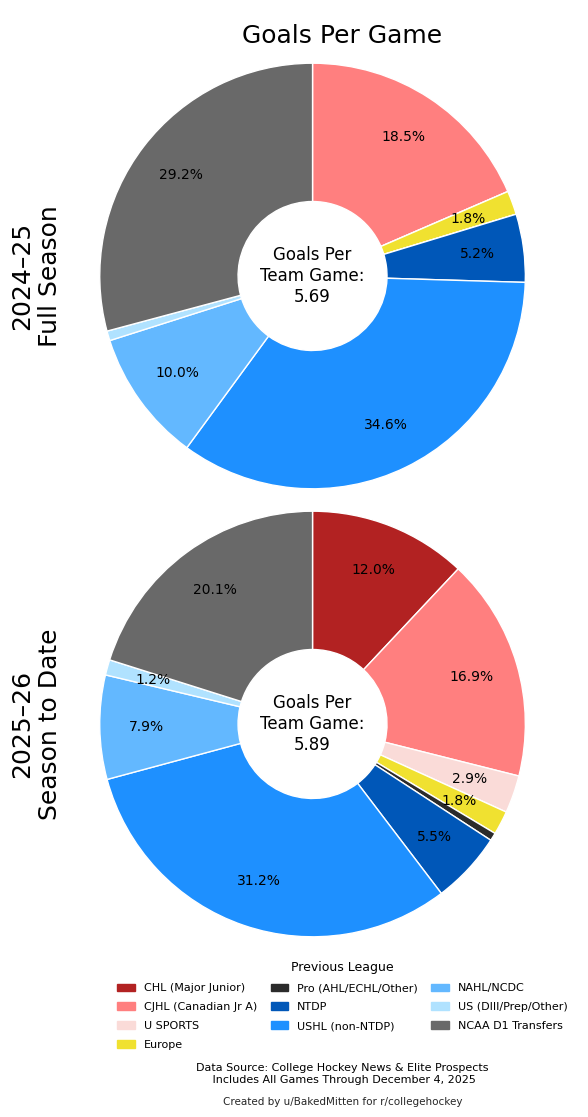

In [33]:
fig = plot_origin_donuts(
    df_prev_agg=agg_24_25_df,
    df_current_agg=agg_df,
    metric="G_per_team_game",
    metric_label="Goals Per Team Game",
    title="Goals Per Game",
    prev_label="2024–25\nFull Season",
    current_label="2025–26\nSeason to Date",
    bin_order=BIN_ORDER,
    bin_color_mapping=bin_color_mapping,
    label_mode="percent",         # keep percent for wedges
    raw_decimals=3,
    min_pct_for_label=0.01,
    figsize=(10, 14),
    data_source_text=f"Data Source: College Hockey News & Elite Prospects\n Includes All Games Through {config.last_game_date}",
    signature_text="Created by u/BakedMitten for r/collegehockey",
    center_value_decimals=2,
)
fig.show()

C:\Users\jbanc\AppData\Local\Temp\ipykernel_10560\3434787790.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


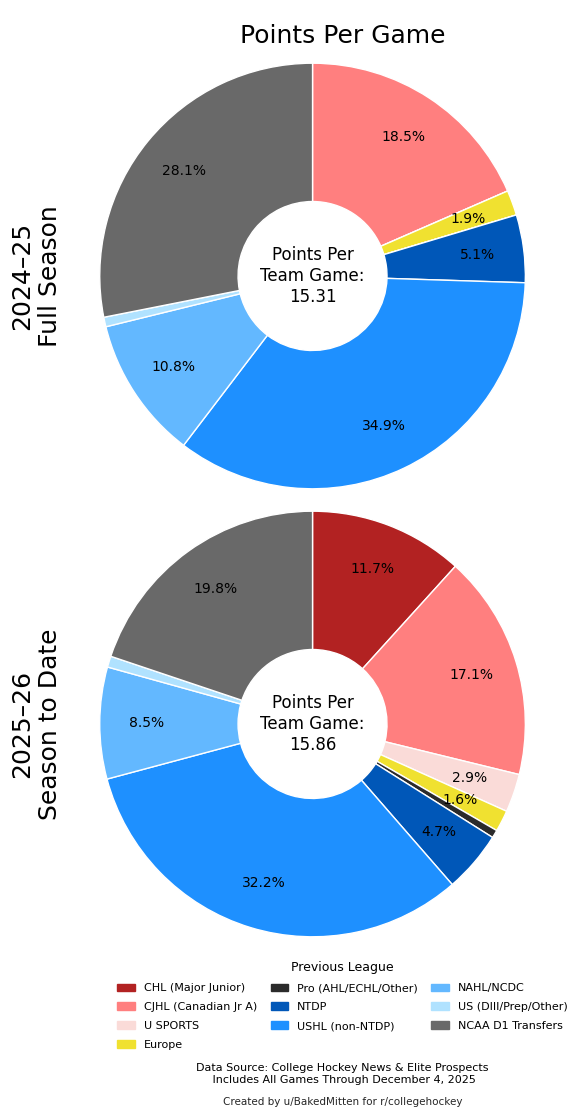

In [34]:
fig = plot_origin_donuts(
    df_prev_agg=agg_24_25_df,
    df_current_agg=agg_df,
    metric="Pts_per_team_game",
    metric_label="Points Per Team Game",
    title="Points Per Game",
    prev_label="2024–25\nFull Season",
    current_label="2025–26\nSeason to Date",
    bin_order=BIN_ORDER,
    bin_color_mapping=bin_color_mapping,
    label_mode="percent",         # keep percent for wedges
    raw_decimals=3,
    min_pct_for_label=0.01,
    figsize=(10, 14),
    data_source_text=f"Data Source: College Hockey News & Elite Prospects\n Includes All Games Through {config.last_game_date}",
    signature_text="Created by u/BakedMitten for r/collegehockey",
    center_value_decimals=2,
)
fig.show()

C:\Users\jbanc\AppData\Local\Temp\ipykernel_10560\608298417.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


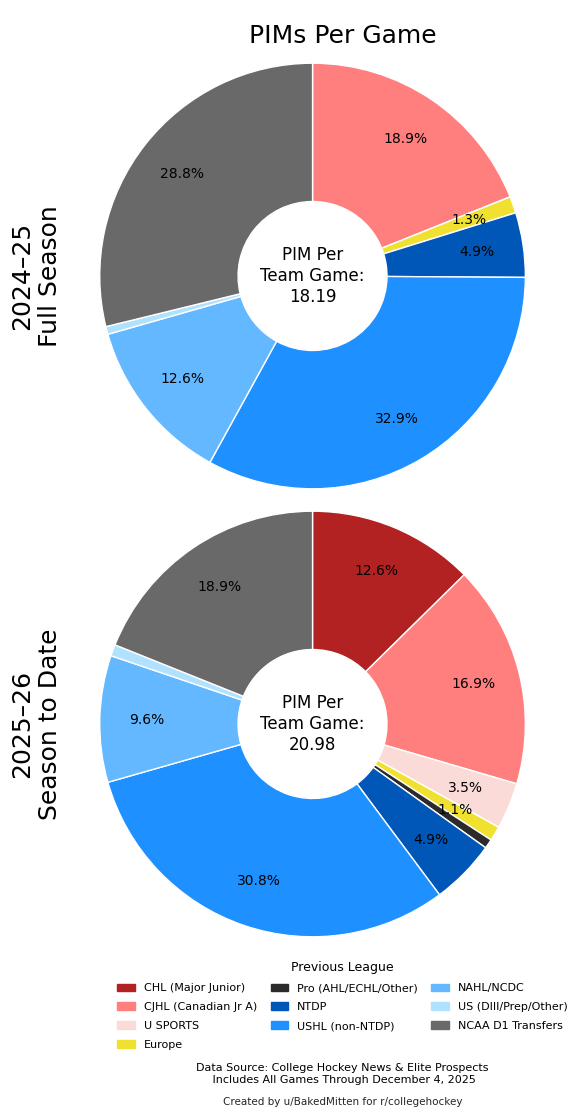

In [35]:
### PIM PER TEAM GAME DONUTS
fig = plot_origin_donuts(
    df_prev_agg=agg_24_25_df,
    df_current_agg=agg_df,
    metric="PIM_per_team_game",
    metric_label="PIMs Per Team Game",
    title="PIMs Per Game",
    prev_label="2024–25\nFull Season",
    current_label="2025–26\nSeason to Date",
    bin_order=BIN_ORDER,
    bin_color_mapping=bin_color_mapping,
    label_mode="percent",         # keep percent for wedges
    raw_decimals=3,
    min_pct_for_label=0.01,
    figsize=(10, 14),
    data_source_text=f"Data Source: College Hockey News & Elite Prospects\n Includes All Games Through {config.last_game_date}",
    signature_text="Created by u/BakedMitten for r/collegehockey",
    center_value_decimals=2,
)
fig.show()

C:\Users\jbanc\AppData\Local\Temp\ipykernel_10560\2036502853.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


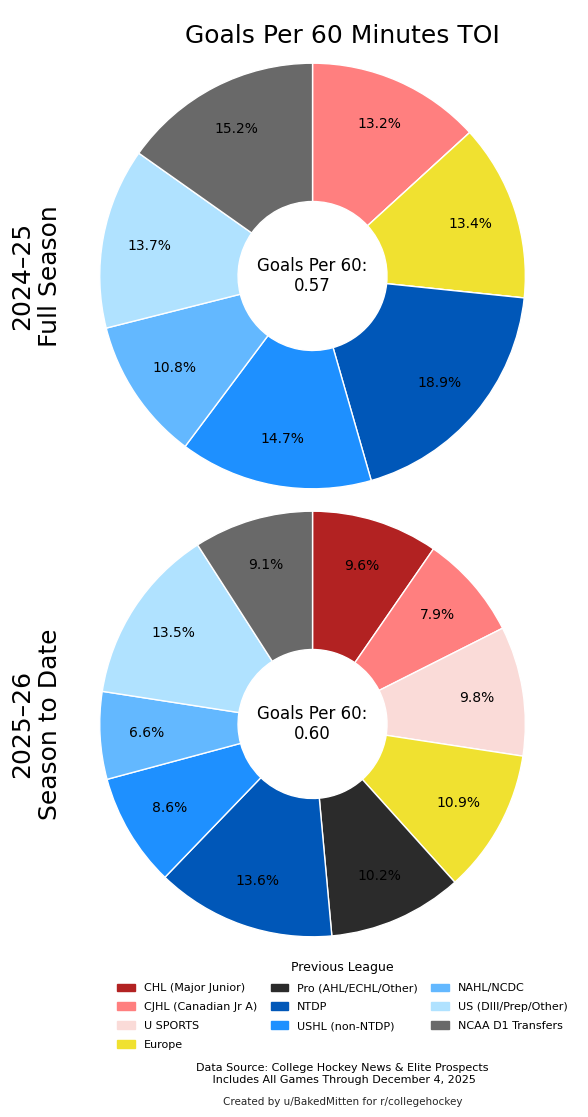

In [36]:
fig = plot_origin_donuts(
    df_prev_agg=agg_24_25_df,
    df_current_agg=agg_df,
    metric="G_per_60min",
    metric_label="Goals Per 60 Minutes",
    title="Goals Per 60 Minutes TOI",
    prev_label="2024–25\nFull Season",
    current_label="2025–26\nSeason to Date",
    bin_order=BIN_ORDER,
    bin_color_mapping=bin_color_mapping,
    label_mode="percent",         # keep percent for wedges
    raw_decimals=3,
    min_pct_for_label=0.01,
    figsize=(10, 14),
    data_source_text=f"Data Source: College Hockey News & Elite Prospects\n Includes All Games Through {config.last_game_date}",
    signature_text="Created by u/BakedMitten for r/collegehockey",
    center_value_decimals=2,
)
fig.show()

C:\Users\jbanc\AppData\Local\Temp\ipykernel_10560\550959204.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


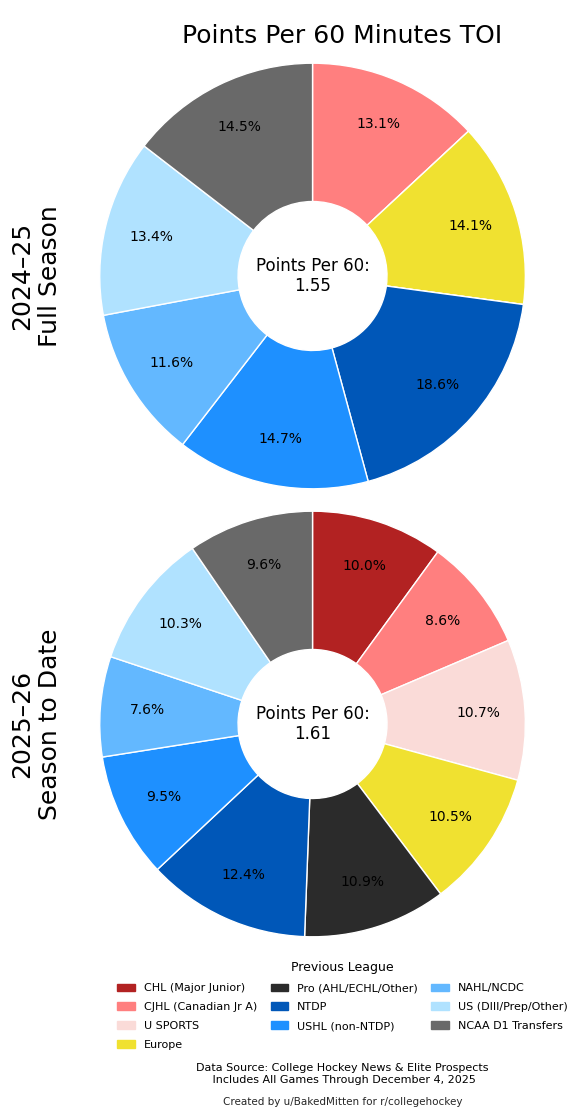

In [37]:
fig = plot_origin_donuts(
    df_prev_agg=agg_24_25_df,
    df_current_agg=agg_df,
    metric="Pts_per_60min",
    metric_label="Points Per 60 Minutes",
    title="Points Per 60 Minutes TOI",
    prev_label="2024–25\nFull Season",
    current_label="2025–26\nSeason to Date",
    bin_order=BIN_ORDER,
    bin_color_mapping=bin_color_mapping,
    label_mode="percent",         # keep percent for wedges
    raw_decimals=3,
    min_pct_for_label=0.01,
    figsize=(10, 14),
    data_source_text=f"Data Source: College Hockey News & Elite Prospects\n Includes All Games Through {config.last_game_date}",
    signature_text="Created by u/BakedMitten for r/collegehockey",
    center_value_decimals=2,
)
fig.show()

C:\Users\jbanc\AppData\Local\Temp\ipykernel_10560\3441601888.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


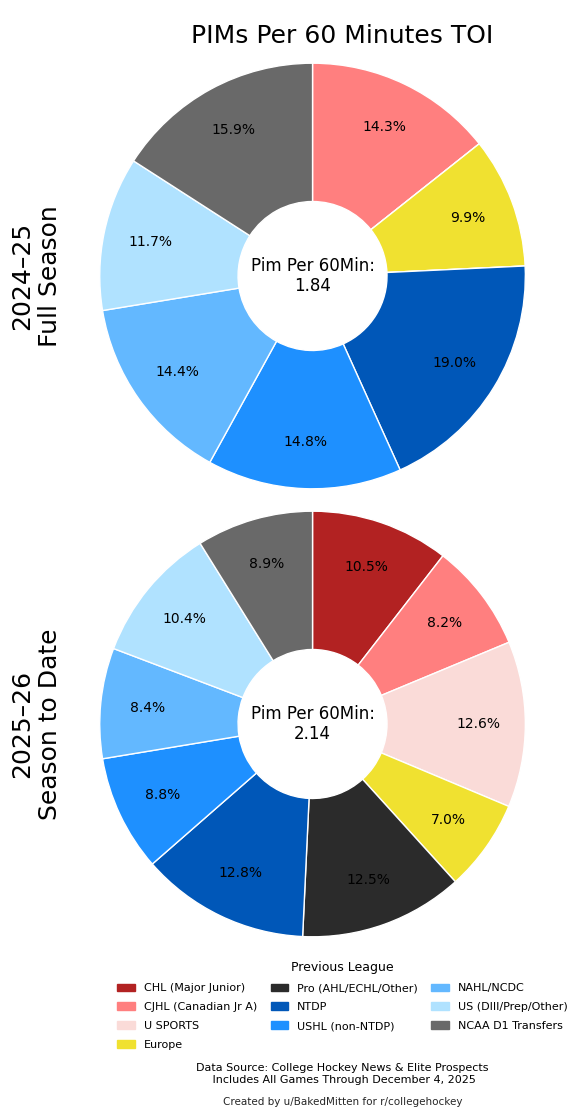

In [38]:
fig = plot_origin_donuts(
    df_prev_agg=agg_24_25_df,
    df_current_agg=agg_df,
    metric="PIM_per_60min",
    metric_label="PIMs Per 60 Minutes",
    title="PIMs Per 60 Minutes TOI",
    prev_label="2024–25\nFull Season",
    current_label="2025–26\nSeason to Date",
    bin_order=BIN_ORDER,
    bin_color_mapping=bin_color_mapping,
    label_mode="percent",         # keep percent for wedges
    raw_decimals=3,
    min_pct_for_label=0.01,
    figsize=(10, 14),
    data_source_text=f"Data Source: College Hockey News & Elite Prospects\n Includes All Games Through {config.last_game_date}",
    signature_text="Created by u/BakedMitten for r/collegehockey",
    center_value_decimals=2,
)
fig.show()

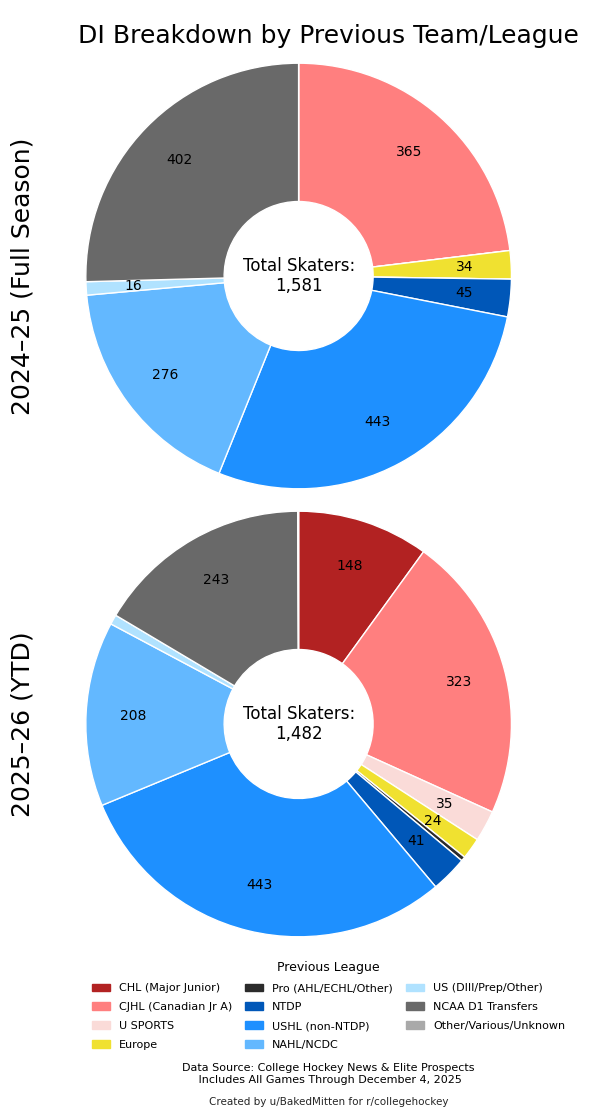

In [39]:
## Call the plot_origin_donuts function to plot Total Players (Player_Count) by Previous League for 24-25 and 25-26 seasons
fig = plot_origin_donuts(
    df_prev_agg=agg_24_25_df,
    df_current_agg=agg_df,
    metric="Player_Count",
    title="DI Breakdown by Previous Team/League",
    prev_label="2024–25 (Full Season)",
    current_label="2025–26 (YTD)",
    label_mode="raw",
    raw_decimals=0,
    min_pct_for_label=0.01,
    figsize=(10, 14),
    data_source_text=f"Data Source: College Hockey News & Elite Prospects\n Includes All Games Through {config.last_game_date}",
    signature_text="Created by u/BakedMitten for r/collegehockey",
    center_value_decimals=2,
)
# Show the plot
plt.show()

In [40]:
# ## Call the plot_origin_donuts function to plot Goals per Game by Previous League for 24-25 vs 25-26 YTD
# fig = plot_origin_donuts(
#     df_prev_agg=agg_24_25_df,
#     df_current_agg=agg_df,
#     metric="G_per_player_game",
#     # title="DI Breakdown by Previous League",
#     prev_label="2024–25 (Full Season)",
#     current_label="2025–26 (YTD)",
#     label_mode="percent",
#     raw_decimals=2,
#     min_pct_for_label=0.01,
#     figsize=(10, 14),
#     data_source_text=f"Data Source: College Hockey News & Elite Prospects\nAll Games Through {config.last_game_date}",
#     signature_text="Created by Your u/BakedMitten for r/collegehockey",
#     center_value_decimals=2,
# )
# # Show the plot
# plt.show()

### Stacked Bar Charts
- not sure if I will be able to do much with these

In [41]:
# # font_prop from your helper
# font_prop = get_exo2_font()

# fig = plot_origin_donuts(
#     df_prev_agg=agg_24_25_df,
#     df_current_agg=agg_df,
#     metric="Player_Count",
#     title="DI Breakdown by Previous League",
#     prev_label="2024–25 (Full Season)",
#     current_label="2025–26 (YTD)",
#     label_mode="percent",             # or "raw", or None
#     raw_decimals=2,
#     min_pct_for_label=0.03,
#     font_prop=font_prop,
#     data_source_text="College Hockey News, augmented by Elite Prospects as of ______",
#     signature_text="Created for r/collegehockey by u/BakedMitten",
#     figsize=(9, 9),
#     center_value_decimals=2,
# )

# fig.savefig("origin_donuts_G.png", dpi=300, bbox_inches="tight")
# plt.show()


In [42]:
agg_df.head(11)

,Prev_League_Bin,Player_Count,Games_Played,Avg_Games Played,G,A,Pts,PlusMinus,Shots,TOI_sec,...,Pts_per_game,PlusMinus_per_game,Shots_per_game,TOI_sec_per_game,PIM_per_game,G_per_team_game,A_per_team_game,Pts_per_team_game,Shots_per_team_game,PIM_per_team_game
0,NTDP,41,563,13.731707,145,188,333,61,1062,559360,...,0.591474,0.108348,1.886323,993.534636,0.831261,0.321508,0.416851,0.738359,2.354767,1.037694
1,USHL (non‑NTDP),443,5298,11.959368,828,1478,2306,245,8553,5061084,...,0.435259,0.046244,1.614383,955.281993,0.549453,1.835920,3.277162,5.113082,18.964523,6.454545
2,NAHL/NCDC,208,1979,9.514423,210,397,607,-257,2540,1664336,...,0.306721,-0.129864,1.283477,840.998484,0.459828,0.465632,0.880266,1.345898,5.631929,2.017738
3,US (DIII/Prep/Other),11,125,11.363636,31,29,60,2,240,121210,...,0.480000,0.016000,1.920000,969.680000,0.656000,0.068736,0.064302,0.133038,0.532151,0.181818
4,CHL (Major Junior),148,1874,12.662162,319,519,838,-68,3224,1745301,...,0.447172,-0.036286,1.720384,931.323906,0.637673,0.707317,1.150776,1.858093,7.148559,2.649667
5,CJHL (Canadian Jr A),323,3434,10.631579,450,774,1224,-154,4733,2980669,...,0.356436,-0.044846,1.378276,867.987478,0.465929,0.997783,1.716186,2.713969,10.494457,3.547672
6,U SPORTS,35,420,12.000000,76,132,208,-20,693,406368,...,0.495238,-0.047619,1.650000,967.542857,0.795238,0.168514,0.292683,0.461197,1.536585,0.740576
7,Europe,24,264,11.000000,48,68,116,13,360,231207,...,0.439394,0.049242,1.363636,875.784091,0.397727,0.106430,0.150776,0.257206,0.798226,0.232816
8,NCAA D1 Transfers,243,3130,12.880658,535,885,1420,-27,5359,3100820,...,0.453674,-0.008626,1.712141,990.677316,0.572524,1.186253,1.962306,3.148559,11.882483,3.973392
9,Pro (AHL/ECHL/Other),5,70,14.000000,16,27,43,10,124,82485,...,0.614286,0.142857,1.771429,1178.357143,0.957143,0.035477,0.059867,0.095344,0.274945,0.148559


In [43]:
# origin_df = agg_df.copy()

# metrics = ("G_per_game", "A_per_game")

# fig, ax = plot_origin_stacked_stats(
#     origin_df,
#     bin_color_mapping,
#     metrics=metrics,
#     label_mode="raw",
#     raw_decimals=2,
#     min_pct_for_label=0.05,
#     title="Roster Construction by Origin (Stacked Stats)",
#     subtitle="2023-24 NCAA Season",
#     footnote="Data source: College Hockey News | Regular Season Only",
#     output_path="../../TEMP/roster_construction_by_origin_stacked_stats.png"
# )

In [44]:
# ### Call The New Viz Function to create stacked bar plot of origin stats - This is by Player

# origin_df = agg_df.copy()

# metrics = ("G_per_player", "A_per_player", "Pts_per_player", "Shots_per_player", "TOI_sec_per_player", "PIM_per_player")

# fig, ax = plot_origin_stacked_stats(
#     df=origin_df,
#     bin_color_mapping=bin_color_mapping,
#     metrics=metrics,
#     normalize=True,  # 100% stacked (shares)
#     sort_bins_by="Player_Count",
#     title="How DI Rosters Are Built by Origin",
#     # subtitle="Share of players, games, goals, assists, points, and shots by previous team/league",
#     footnote="Data source: College Hockey News | Includes all games in current season",
#     output_path="plots/origin_stacked_stats.png",
# )


In [45]:
# # Stacked bar with per game stats
# metrics_per_game = ("G_per_game", "A_per_game", "Pts_per_game",  "PIM_per_game")

# fig, ax = plot_origin_stacked_stats(
#     df=origin_df,
#     bin_color_mapping=bin_color_mapping,
#     metrics=metrics_per_game,
#     normalize=True,  # 100% stacked (shares)
#     sort_bins_by="Player_Count",
#     title="How DI Rosters Are Built by Origin (Per Game)",
#     footnote="Data source: College Hockey News | Includes all games in current season",
#     output_path="plots/origin_stacked_stats_per_game.png",
# )

In [46]:
# metrics_raw = ("G_per_game", "A_per_game")

# ### Plot with raw count (not normalized)
# fig, ax = plot_origin_stacked_stats(
#     df=origin_df,
#     label_mode="raw",
#     bin_color_mapping=bin_color_mapping,
#     raw_decimals=3,
#     metrics=metrics_raw,
#     normalize=False,  # raw counts
#     sort_bins_by="Player_Count",
#     title="How DI Rosters Are Built by Origin (Raw Counts)",
#     footnote="Data source: College Hockey News | Includes all games in current season",
#     output_path="plots/origin_stacked_stats_raw_counts.png",
# )

## Bin By Country

In [47]:
### Do The Aggrigation by Home Country
country_agg_stats = {
    "Games_Played": "sum",
    "G": "sum",
    "A": "sum",
    "Pts": "sum",
    "PlusMinus": "sum",
    "Shots": "sum",
    "TOI_sec": "sum",
    "PIM": "sum",
}
country_agg_df = merged_df.groupby("Country").agg(country_agg_stats).reset_index()
print(country_agg_df.head(20))

## Get count of players in each Country and calculate per player averages
country_player_counts = (df["Country"]
                    .value_counts(dropna=False)
                    .fillna(0).astype(int))
# print("Player Counts by Country")
# print(country_player_counts.reset_index().rename(columns={"index":"Country","Country":" Count"}))

           Country  Games_Played     G     A   Pts  PlusMinus  Shots  TOI_sec  \
0          Austria            39     8    16    24          2     65    38182   
1          Belarus            18     6     5    11         -2     25    14088   
2           Canada          6335  1014  1713  2727       -165  10146  5854648   
3   Cayman Islands            19     0     9     9         -8     27    20228   
4          Croatia             9     1     1     2          3     19     5169   
5   Czech Republic            86    22    29    51        -19    174    90863   
6          Czechia            15     2     3     5        -10     29    15619   
7          Finland           228    38    54    92          5    314   200685   
8          Germany            15     2     4     6          0     29    14417   
9    Great Britain            11     1     1     2          2     13     7611   
10         Hungary            13     1     2     3          3      9    11940   
11           Italy          

In [48]:
## Calculate per player averages for each aggregated stat by Country
country_player_counts = country_player_counts.reindex(country_agg_df["Country"])
for stat in country_agg_stats.keys():
    country_agg_df[stat + "_per_player"] = country_agg_df[stat] / country_player_counts.values

# Calculate per game averages for each aggregated stat by Country
for stat in country_agg_stats.keys():
    country_agg_df[stat + "_per_game_played"] = country_agg_df[stat] / country_agg_df["Games_Played"]

## Calculate rate stats per 60 minutes for each aggregated stat by Country
for stat in country_agg_stats.keys():
    country_agg_df[stat + "_per_60min"] = (country_agg_df[stat] / country_agg_df["TOI_sec"]) * 3600

country_agg_df.info()
country_agg_df.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       23 non-null     object 
 1   Games_Played                  23 non-null     int64  
 2   G                             23 non-null     int64  
 3   A                             23 non-null     int64  
 4   Pts                           23 non-null     int64  
 5   PlusMinus                     23 non-null     int64  
 6   Shots                         23 non-null     int64  
 7   TOI_sec                       23 non-null     int64  
 8   PIM                           23 non-null     int64  
 9   Games_Played_per_player       23 non-null     float64
 10  G_per_player                  23 non-null     float64
 11  A_per_player                  23 non-null     float64
 12  Pts_per_player                23 non-null     float64
 13  PlusMin

,Country,Games_Played,G,A,Pts,PlusMinus,Shots,TOI_sec,PIM,Games_Played_per_player,...,TOI_sec_per_game_played,PIM_per_game_played,Games_Played_per_60min,G_per_60min,A_per_60min,Pts_per_60min,PlusMinus_per_60min,Shots_per_60min,TOI_sec_per_60min,PIM_per_60min
0,Austria,39,8,16,24,2,65,38182,10,13.000000,...,979.025641,0.256410,3.677125,0.754282,1.508564,2.262846,0.188571,6.128542,3600.0,0.942853
1,Belarus,18,6,5,11,-2,25,14088,4,9.000000,...,782.666667,0.222222,4.599659,1.533220,1.277683,2.810903,-0.511073,6.388416,3600.0,1.022147
2,Canada,6335,1014,1713,2727,-165,10146,5854648,3761,11.666667,...,924.174901,0.593686,3.895367,0.623505,1.053317,1.676822,-0.101458,6.238735,3600.0,2.312624
3,Cayman Islands,19,0,9,9,-8,27,20228,8,9.500000,...,1064.631579,0.421053,3.381451,0.000000,1.601740,1.601740,-1.423769,4.805220,3600.0,1.423769
4,Croatia,9,1,1,2,3,19,5169,2,9.000000,...,574.333333,0.222222,6.268137,0.696460,0.696460,1.392919,2.089379,13.232734,3600.0,1.392919
5,Czech Republic,86,22,29,51,-19,174,90863,46,14.333333,...,1056.546512,0.534884,3.407328,0.871642,1.148983,2.020624,-0.752782,6.893895,3600.0,1.822524
6,Czechia,15,2,3,5,-10,29,15619,2,15.000000,...,1041.266667,0.133333,3.457328,0.460977,0.691466,1.152443,-2.304885,6.684167,3600.0,0.460977
7,Finland,228,38,54,92,5,314,200685,93,10.857143,...,880.197368,0.407895,4.089992,0.681665,0.968682,1.650348,0.089693,5.632708,3600.0,1.668286
8,Germany,15,2,4,6,0,29,14417,4,15.000000,...,961.133333,0.266667,3.745578,0.499410,0.998821,1.498231,0.000000,7.241451,3600.0,0.998821
9,Great Britain,11,1,1,2,2,13,7611,8,11.000000,...,691.909091,0.727273,5.202996,0.473000,0.473000,0.945999,0.945999,6.148995,3600.0,3.783997


## Bin By State / Province

In [49]:
## Examine the State_Province column value counts
state_prov_counts = merged_df['State_Province'].value_counts()
print("State/Province Value Counts")
print(state_prov_counts)

State/Province Value Counts
State_Province
Minnesota           187
Ontario             181
British Columbia    107
Alberta              99
New York             85
                   ... 
Oklahoma              1
JPN                   1
Italy                 1
Scotland              1
RUS                   1
Name: count, Length: 69, dtype: int64


In [50]:

## Filter out any rows that don't have USA or CAN in the Country column

# print length of merged_df before filtering
print("Merged DataFrame shape before filtering for USA/CAN:", merged_df.shape)
us_can_df = merged_df[(merged_df["Country"] == "USA") | (merged_df["Country"] == "Canada")]

# print length of us_can_df after filtering
print("Filtered DataFrame shape for USA/CAN:", us_can_df.shape)

# Print summary of State_Province values in us_can_df
print("USA/CAN DataFrame State/Province Value Counts")
# USA / Canada Country Value Counts
print(us_can_df['Country'].value_counts())
# State Province Value Counts
print(us_can_df['State_Province'].value_counts())

# Check State Province values of rows filtered out
# filtered_out_df = merged_df[~merged_df.index.isin(us_can_df.index)]
# print("Filtered Out DataFrame State/Province Value Counts")
# print(filtered_out_df['State_Province'].value_counts())


Merged DataFrame shape before filtering for USA/CAN: (1482, 32)
Filtered DataFrame shape for USA/CAN: (1365, 32)
USA/CAN DataFrame State/Province Value Counts
Country
USA       822
Canada    543
Name: count, dtype: int64
State_Province
Minnesota                    187
Ontario                      181
British Columbia             107
Alberta                       99
New York                      85
Massachusetts                 74
Michigan                      70
Quebec                        67
Illinois                      55
California                    45
New Jersey                    38
Saskatchewan                  35
Pennsylvania                  30
Manitoba                      28
Wisconsin                     26
Connecticut                   26
New Hampshire                 14
Colorado                      14
North Dakota                  14
Ohio                          13
Maryland                      13
Missouri                      13
Alaska                        12
India

In [51]:
### Group and aggregate stats by State_Province for USA and CAN players
state_prov_agg_stats = {
    "Games_Played": "sum",
    "G": "sum",
    "A": "sum",
    "Pts": "sum",
    "PlusMinus": "sum",
    "Shots": "sum",
    "TOI_sec": "sum",
    "PIM": "sum",
}

state_prov_agg_df = us_can_df.groupby("State_Province").agg(state_prov_agg_stats).reset_index()
print(state_prov_agg_df.head(20))

## Get count of players in each State_Province and calculate per player averages
state_prov_player_counts = (us_can_df["State_Province"]
                    .value_counts(dropna=False)
                    .fillna(0).astype(int))
print("Player Counts by State/Province")
print(state_prov_player_counts.reset_index().rename(columns={"index":"State/Province","State_Province":" Count"}))

### Divide aggregated stats by player counts to get per player averages by State_Province
state_prov_player_counts = state_prov_player_counts.reindex(state_prov_agg_df["State_Province"])
for stat in state_prov_agg_stats.keys():
    state_prov_agg_df[stat + "_per_player"] = state_prov_agg_df[stat] / state_prov_player_counts.values

## Calculate rate stats per 60 minutes for each aggregated stat by State_Province
for stat in state_prov_agg_stats.keys():
    state_prov_agg_df[stat + "_per_60min"] = (state_prov_agg_df[stat] / state_prov_agg_df["TOI_sec"]) * 3600

# Calculate per game averages for each aggregated stat by State_Province
for stat in state_prov_agg_stats.keys():
    state_prov_agg_df[stat + "_per_player_per_game_played"] = state_prov_agg_df[stat] / state_prov_agg_df["Games_Played"]
# state_prov_agg_df.info()
# state_prov_agg_df.head(20)

      State_Province  Games_Played    G    A   Pts  PlusMinus  Shots  TOI_sec  \
0             Alaska           136   19   40    59        -17    245   139580   
1            Alberta          1170  172  298   470        -40   1758  1052580   
2            Arizona           131   15   40    55          8    160   117684   
3   British Columbia          1264  174  318   492        -36   1958  1153173   
4         California           468   74  117   191         -1    690   405621   
5           Colorado           138   11   19    30          3    149   118438   
6        Connecticut           283   38   67   105         26    461   253937   
7           Delaware            13    2    4     6          2     10     9338   
8            Florida           132   25   50    75         -4    226   125832   
9            Georgia            79    6   20    26          1    104    61945   
10             Idaho            14    1    3     4         -1     13    20176   
11          Illinois        

## MAKE A MAP/S FOR REDACTED CHARTS ON REDDIT

In [52]:
# # Check path of shapefile

# shapefile_path = "../../data/vault/10m_state_province_file.shp"

# # try to load file
# with 


In [53]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path



def plot_state_prov_choropleth(
    state_prov_agg_df: pd.DataFrame,
    metric: str = "G",                     # or "Pts"
    shapefile_path: str = "..\\..\\data\\vault\\state_province_geo\\ne_110m_admin_1_states_provinces.shp",
    output_path: str | Path = "state_prov_map_G.png",
    title: str | None = None,
    cmap: str = "YlGnBu",                  # nice smooth gradient
    dpi: int = 300
):
    """
    Plot a static choropleth map of US states + Canadian provinces using
    state_prov_agg_df, which must have columns:
        - 'State_Province'
        - the chosen metric (e.g. 'G' or 'Pts')
    """

    # --- load the shapefile ---
    admin1 = gpd.read_file(shapefile_path)

    # Natural Earth usually has both 'name' and 'name_en'
    # After admin1 = gpd.read_file(shapefile_path)

    # See what columns you have (optional, but handy):
    print("Shapefile columns:", admin1.columns.tolist())

    # Try a few common field names
    candidate_cols = ["name_en", "name", "name_1", "NAME_1", "state_name", "STATE_NAME"]
    name_col = None
    for col in candidate_cols:
        if col in admin1.columns:
            name_col = col
            break

    if name_col is None:
        raise ValueError(
            "Could not find a suitable name column in shapefile. "
            "Available columns are: "
            + ", ".join(admin1.columns.astype(str))
        )

    admin1["region_name"] = admin1[name_col]

    

    # Keep only USA + Canada to match your table
    mask = admin1["admin"].isin(["United States of America", "Canada"])
    regions = admin1.loc[mask].copy()

    # --- join your data onto the geometry ---
    # Make sure the key column is string
    state_prov_agg_df = state_prov_agg_df.copy()
    state_prov_agg_df["State_Province"] = state_prov_agg_df["State_Province"].astype(str)

    merged = regions.merge(
        state_prov_agg_df,
        left_on="region_name",
        right_on="State_Province",
        how="left",
        validate="1:1"
    )

    if metric not in merged.columns:
        raise ValueError(f"Metric '{metric}' is not a column in the dataframe.")

    # --- plotting ---
    fig, ax = plt.subplots(figsize=(8, 10))  # tweak for aspect/Reddit

    # Blank-ish style: no axes, white background
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # Draw boundaries lightly so it's minimalist
    merged.boundary.plot(ax=ax, linewidth=0.3, color="lightgrey")

    # Choropleth fill
    merged.plot(
        column=metric,
        ax=ax,
        cmap=cmap,
        linewidth=0.4,
        edgecolor="black",
        legend=True,
        legend_kwds={
            "label": metric,
            "shrink": 0.5,
            "orientation": "vertical"
        },
        missing_kwds={
            "color": "white",
            "edgecolor": "lightgrey",
            "hatch": "///",
            "label": "No data"
        }
    )

    # Nicely centered, mostly-blank map
    ax.set_axis_off()
    ax.set_aspect("equal")

    if title is None:
        title = f"{metric} by State / Province (College Hockey)"
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)

    # Optional subtitle / data source
    # ax.text(0.5, 0.03, "Data: Your College Hockey DB",
    #         transform=fig.transFigure, ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    output_path = Path(output_path)
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight", facecolor="white")
    # plt.close(fig)
    # Show the plot
    plt.show()

    print(f"Map saved to: {output_path}")



## Call the function to plot goals by state/province
plot_state_prov_choropleth(
    state_prov_agg_df=state_prov_agg_df,
    metric="G",
    shapefile_path="../../data/vault/10m_state_province_file.shp",
    output_path=plot_folder / "state_prov_map_G.png",
    title="Goals by State / Province (College Hockey)",
    cmap="YlGnBu",
    dpi=300
)